In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import random
import math
import numpy as np
import copy
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score, precision_score, recall_score
import cv2
from PIL import Image
import glob
import os

In [2]:
IMG_HEIGHT = 256 
IMG_WIDTH = 256
batch_size = 16
epochs = 100
learning_rate = 1e-3
patience = 12
TOPK_ANOMALY_RATIO = 0.01

In [3]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            # (0)-(1)
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (2)-(3)
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (4)-(5)
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (6)-(7)
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (8)-(9)
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (10)
            nn.Conv2d(512, 16, kernel_size=3, stride=1, padding=1)
        )
        
        self.decoder = nn.Sequential(
            # (0)-(1)
            nn.ConvTranspose2d(16, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            # (2)-(3)
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (4)-(5)
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (6)-(7)
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (8)-(9)
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (10)-(11)
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Autoencoder().to(device)

In [ ]:
import os
import cv2
import numpy as np
from PIL import Image
import glob
import random
import matplotlib.pyplot as plt

# ==========================================================
# 1. DEFINÍCIA FUNKCIÍ (Iba Odlesky: > 230)
# ==========================================================
def remove_glare_inpaint(img_rgb):
    """
    Detekcia iba extrémnych odleskov (> 230) pre metódu Inpaint.
    Tiene nechávame úplne bez zmeny (dôležité pre zachovanie defektov!).
    """
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    
    # Maska odleskov (extrémne svetlé)
    _, mask_glare = cv2.threshold(gray, 225, 255, cv2.THRESH_BINARY)
    
    # Jemné roztiahnutie masky
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask_dilated = cv2.dilate(mask_glare, kernel)
    
    if np.count_nonzero(mask_dilated) == 0:
        return img_rgb.copy(), mask_dilated
        
    # Inpainting opraví len biele vypálené fľaky
    result = cv2.inpaint(img_rgb, mask_dilated, inpaintRadius=3, flags=cv2.INPAINT_TELEA)
    return result, mask_dilated

def remove_glare_hsv(img_rgb):
    """
    Zráža IBA extrémne svetlo (> 230) na 230.
    Tmavé miesta (tiene a defekty) ignoruje.
    """
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    V = hsv[:, :, 2]
    
    # Zhora (Odlesky) - Limitujeme na 230
    V[V > 230] = 230
    
    hsv[:, :, 2] = V
    result = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
    return result

# ==========================================================
# 2. HLAVNÝ SKRIPT NA VYTVORENIE DATASETU
# ==========================================================
def generate_datasets(base_source_dir, target_root_hsv, target_root_inpaint):
    print("--- ŠTART GENEROVANIA BEZPEČNÝCH DATASETOV (IBA ODLESKY) ---")
    
    for split in ['train', 'val', 'test']:
        split_path = os.path.join(base_source_dir, split)
        if not os.path.exists(split_path):
            print(f"Priečinok {split} nebol nájdený, preskakujem...")
            continue
            
        for cls in os.listdir(split_path):
            source_folder = os.path.join(split_path, cls)
            if not os.path.isdir(source_folder):
                continue
            
            dest_hsv = os.path.join(target_root_hsv, split, cls)
            dest_inpaint = os.path.join(target_root_inpaint, split, cls)
            
            os.makedirs(dest_hsv, exist_ok=True)
            os.makedirs(dest_inpaint, exist_ok=True)
            
            img_paths = glob.glob(os.path.join(source_folder, "*.*"))
            print(f"Spracovávam {split}/{cls} ({len(img_paths)} obrázkov)...")
            
            for img_path in img_paths:
                try:
                    img_np = np.array(Image.open(img_path).convert("RGB"))
                    
                    # Aplikácia zjednotených metód (Iba na odlesky)
                    processed_hsv = remove_glare_hsv(img_np)
                    processed_inpaint, _ = remove_glare_inpaint(img_np) 
                    
                    filename = os.path.basename(img_path)
                    name, _ = os.path.splitext(filename)
                    
                    # Uloženie
                    Image.fromarray(processed_hsv).save(os.path.join(dest_hsv, f"{name}.png"))
                    Image.fromarray(processed_inpaint).save(os.path.join(dest_inpaint, f"{name}.png"))
                    
                except Exception as e:
                    print(f"Chyba pri {img_path}: {e}")

    print("\n--- HOTOVO! DATASETY SÚ ULOŽENÉ ---")
    print(f"-> {target_root_hsv}")
    print(f"-> {target_root_inpaint}")

# ==========================================================
# 3. VIZUALIZÁCIA (5x GOOD, 5x DEFEKT)
# ==========================================================
def show_visual_comparison():
    print("\nGenerujem vizuálne porovnanie: 5x GOOD a 5x DEFEKT...")

    good_paths = glob.glob("val/good/*.*") + glob.glob("test/good/*.*") + glob.glob("train/good/*.*")
    defect_paths = glob.glob("val/bad*/*.*") + glob.glob("test/bad*/*.*")

    num_good = min(5, len(good_paths))
    num_defect = min(5, len(defect_paths))

    sampled_good = random.sample(good_paths, num_good)
    sampled_defect = random.sample(defect_paths, num_defect)

    all_sampled_paths = sampled_good + sampled_defect
    num_samples = len(all_sampled_paths)

    if num_samples == 0:
        print("Chyba: Nenašli sa žiadne obrázky. Skontroluj, či sú cesty k zložkám správne.")
        return

    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples), squeeze=False)

    for i, img_path in enumerate(all_sampled_paths):
        img_pil = Image.open(img_path).convert("RGB")
        img_np = np.array(img_pil)

        res_inpaint, generated_mask = remove_glare_inpaint(img_np)
        res_hsv = remove_glare_hsv(img_np)

        img_name = os.path.basename(img_path)
        folder_name = os.path.basename(os.path.dirname(img_path))

        if "good" in folder_name.lower():
            status = "OK (Good)"
            color = "green"
        else:
            status = f"DEFEKT ({folder_name})"
            color = "red"

        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f"Originál [{status}]\n({img_name})", color=color, fontweight='bold', fontsize=14)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(generated_mask, cmap='gray')
        axes[i, 1].set_title("Maska (Iba Jas > 230)", fontsize=14)
        axes[i, 1].axis('off')

        axes[i, 2].imshow(res_inpaint)
        axes[i, 2].set_title("Inpaint (Iba Odlesky)", fontsize=14)
        axes[i, 2].axis('off')

        axes[i, 3].imshow(res_hsv)
        axes[i, 3].set_title("HSV (Iba Odlesky)", fontsize=14)
        axes[i, 3].axis('off')

    plt.tight_layout()
    plt.show()

# ==========================================================
# 4. SPUSTENIE
# ==========================================================
# Najprv vytvorí datasety na C:
#generate_datasets(
#    base_source_dir=".", 
#    target_root_hsv=r"C:\dataset_basic_hsv", 
#    target_root_inpaint=r"C:\dataset_basic_inpaint"
#)

# Následne hneď vykreslí grafy na kontrolu
show_visual_comparison()

In [ ]:
import os
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# =========================================================
# 1. NASTAVENIE CIEĽOVÉHO DATASETU
# =========================================================
# "basic_hsv" / "basic_inpaint"
METHOD_TO_TRAIN = "basic_inpaint"  

if METHOD_TO_TRAIN == "basic_hsv":
    root_dir = r"C:\dataset_basic_hsv"
elif METHOD_TO_TRAIN == "basic_inpaint":
    root_dir = r"C:\dataset_basic_inpaint"

# =========================================================
# 2. TRANSFORMÁCIE 
# =========================================================
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor()
])

transform_eval = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor()
])

# =========================================================
# 3. NAČÍTANIE TRAIN (Iba 'good' obrázky pre Autoencoder)
# =========================================================
dataset_train_full = datasets.ImageFolder(os.path.join(root_dir, "train"), transform=transform_train)
good_idx_train = dataset_train_full.class_to_idx["good"]

# Vyfiltrujeme len "good" 
train_good_indices = [i for i, label in enumerate(dataset_train_full.targets) if label == good_idx_train]
dataset_train = Subset(dataset_train_full, train_good_indices)

train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

# =========================================================
# 4. NAČÍTANIE VAL 
# =========================================================
dataset_val = datasets.ImageFolder(os.path.join(root_dir, "val"), transform=transform_eval)
good_idx_val = dataset_val.class_to_idx["good"]

val_good_indices = [i for i, label in enumerate(dataset_val.targets) if label == good_idx_val]
val_def_indices = [i for i, label in enumerate(dataset_val.targets) if label != good_idx_val]

val_good_loader = DataLoader(Subset(dataset_val, val_good_indices), batch_size=batch_size, shuffle=False)
val_def_loader = DataLoader(Subset(dataset_val, val_def_indices), batch_size=batch_size, shuffle=False)

# =========================================================
# 5. NAČÍTANIE TEST 
# =========================================================
dataset_test = datasets.ImageFolder(os.path.join(root_dir, "test"), transform=transform_eval)
good_idx_test = dataset_test.class_to_idx["good"]

test_good_indices = [i for i, label in enumerate(dataset_test.targets) if label == good_idx_test]
test_def_indices = [i for i, label in enumerate(dataset_test.targets) if label != good_idx_test]

test_good_loader = DataLoader(Subset(dataset_test, test_good_indices), batch_size=batch_size, shuffle=False)
test_def_loader = DataLoader(Subset(dataset_test, test_def_indices), batch_size=batch_size, shuffle=False)

print(f"TRAIN good: {len(train_good_indices)}")
print(f"VAL good: {len(val_good_indices)}, VAL defect: {len(val_def_indices)}")
print(f"TEST good: {len(test_good_indices)}, TEST defect: {len(test_def_indices)}")

In [ ]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim

save_model_name = f"best_autoencoder_{METHOD_TO_TRAIN}.pth"
print(f"Najlepší model sa bude ukladať ako: {save_model_name}")

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

history_train_loss = []
history_val_loss = []
best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())
early_stop_counter = 0

for epoch in range(epochs):
    # --- TRÉNOVANIE ---
    model.train()
    train_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        outputs = model(images)
        loss = loss_fn(outputs, images)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
    train_loss /= len(train_loader.dataset)
    
    # --- VALIDÁCIA ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, _ in val_good_loader:
            images = images.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, images)
            val_loss += loss.item() * images.size(0)
    val_loss /= len(val_good_loader.dataset)
    
    history_train_loss.append(train_loss)
    history_val_loss.append(val_loss)
    scheduler.step(val_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}] - train_loss: {train_loss:.4f} - val_good_loss: {val_loss:.4f}")
    
    # --- UKLADANIE NAJLEPŠIEHO MODELU ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), save_model_name)  
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        
    if early_stop_counter >= patience:
        print(f"Early stopping na epoche {epoch+1}")
        break

# Načítanie najlepších váh späť do modelu po skončení tréningu
model.load_state_dict(torch.load(save_model_name))
print("Hotovo! Najlepší model je načítaný a pripravený na testovanie.")

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(history_train_loss) + 1), history_train_loss, label='Trénovacia Loss', color='blue')
plt.plot(range(1, len(history_val_loss) + 1), history_val_loss, label='Validačná Loss (Good)', color='green')
plt.title('Priebeh trénovania (Výlučne MSE)')
plt.xlabel('Epocha')
plt.ylabel('Hodnota Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

THRESHOLD Z VALIDÁCIE (MSE Loss)
Best threshold: 0.000323
Best validation F1: 0.896142


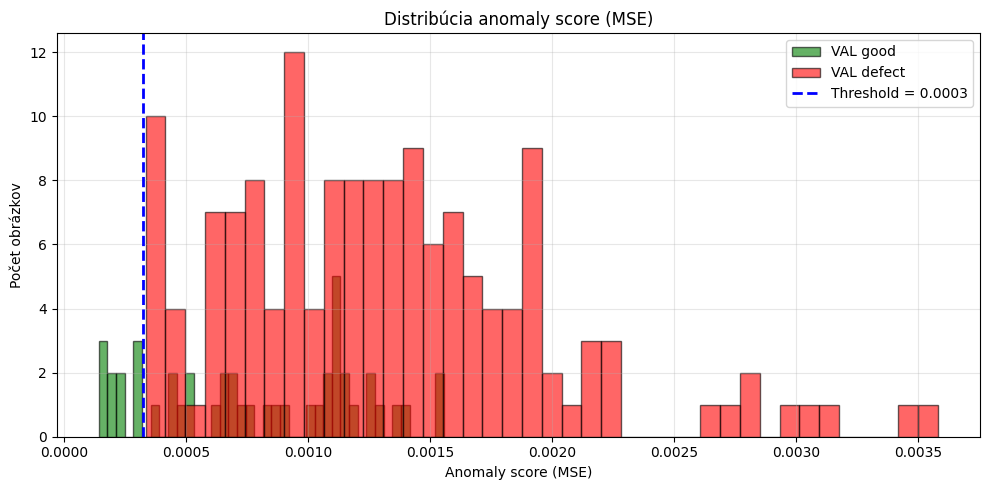

In [8]:
def get_anomaly_scores(loader, model, device):
    scores = []
    model.eval()
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            reconstructions = model(images)
            error_map = torch.square(reconstructions - images)
            anomaly_score = error_map.mean(dim=(1, 2, 3))
            scores.extend(anomaly_score.cpu().numpy())
    return np.array(scores)

val_normal_scores = get_anomaly_scores(val_good_loader, model, device)
val_defect_scores = get_anomaly_scores(val_def_loader, model, device)

y_val_true = np.concatenate([
    np.zeros(len(val_normal_scores), dtype=int),
    np.ones(len(val_defect_scores), dtype=int)
])
y_val_scores = np.concatenate([val_normal_scores, val_defect_scores])

thresholds = np.linspace(y_val_scores.min(), y_val_scores.max(), 500)
best_thresh = None
best_f1 = -1

for thr in thresholds:
    y_val_pred = (y_val_scores > thr).astype(int)
    f1 = f1_score(y_val_true, y_val_pred, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thr

RECON_THRESH = best_thresh

print("=" * 60)
print("THRESHOLD Z VALIDÁCIE (MSE Loss)")
print("=" * 60)
print(f"Best threshold: {RECON_THRESH:.6f}")
print(f"Best validation F1: {best_f1:.6f}")

plt.figure(figsize=(10, 5))
plt.hist(val_normal_scores, bins=40, alpha=0.6, color='green', label='VAL good', edgecolor='black')
plt.hist(val_defect_scores, bins=40, alpha=0.6, color='red', label='VAL defect', edgecolor='black')
plt.axvline(RECON_THRESH, color='blue', linestyle='--', linewidth=2, label=f'Threshold = {RECON_THRESH:.4f}')
plt.title('Distribúcia anomaly score (MSE)')
plt.xlabel('Anomaly score (MSE)')
plt.ylabel('Počet obrázkov')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ANALÝZA NAJHORŠÍCH 'DOBRÝCH' OBRAZOV (Odlesky/Problémy)


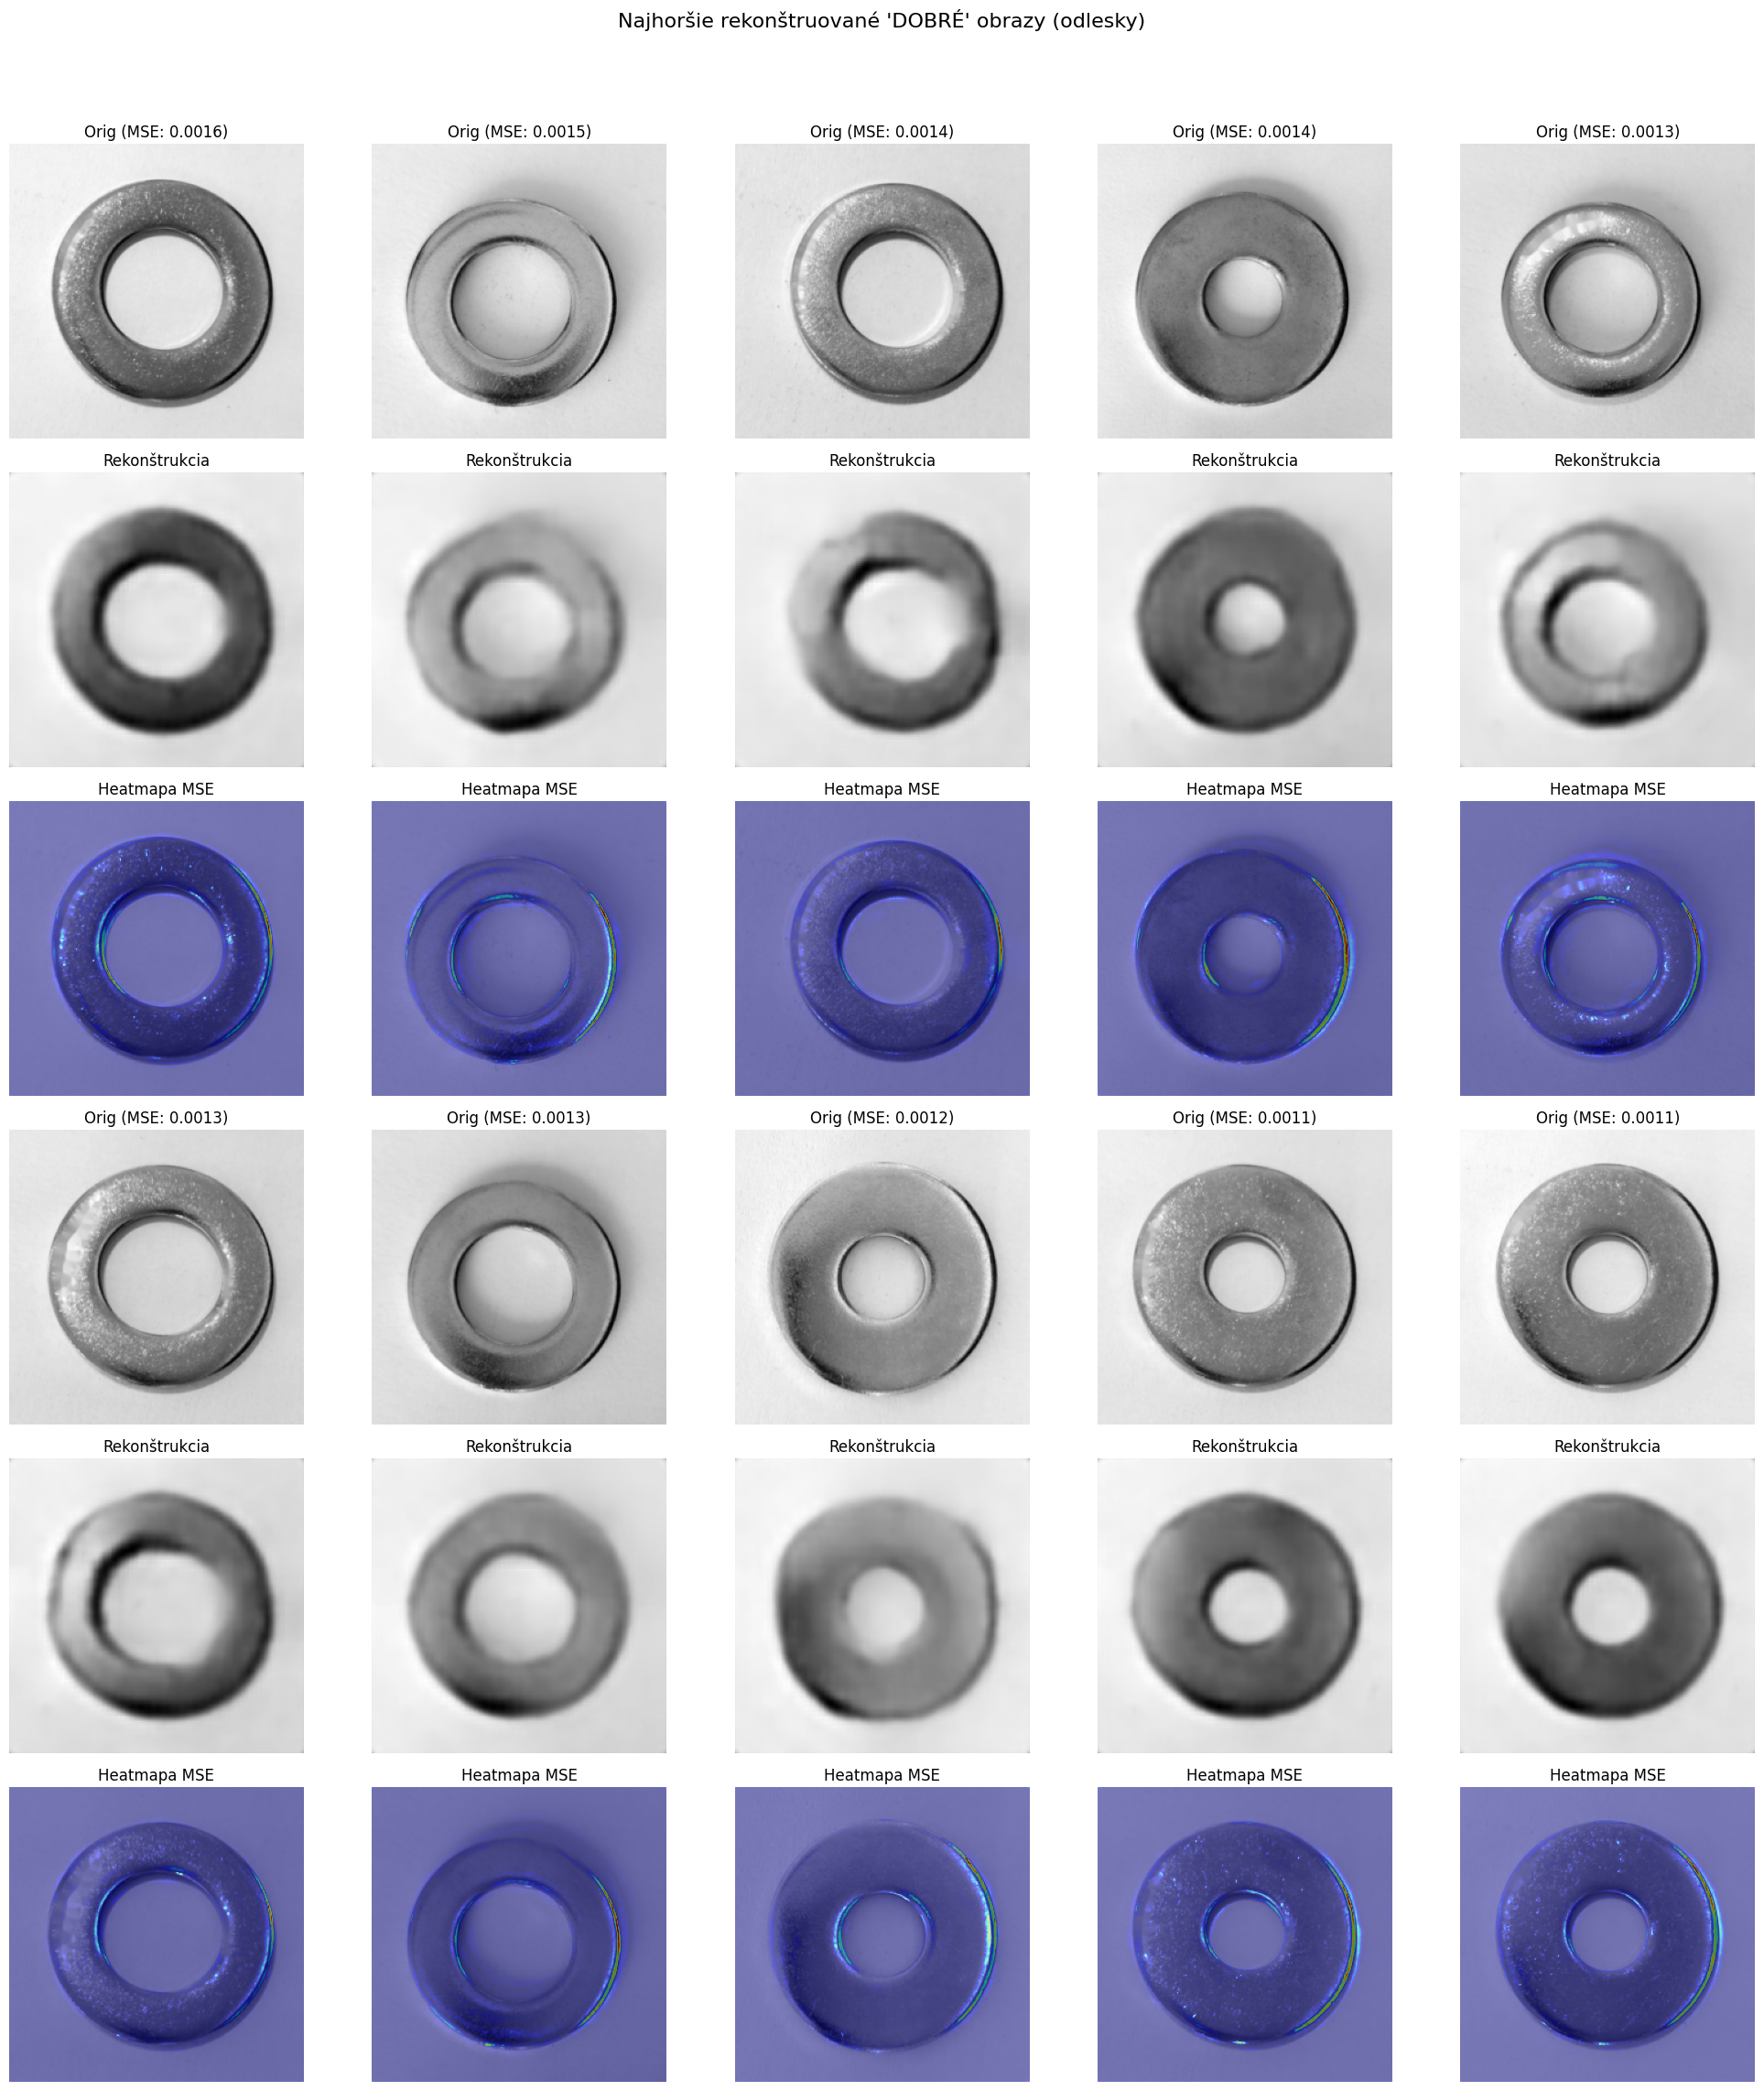

In [9]:
def show_worst_good_images(model, loader, device, num_images=10, num_cols=5):
    print("=" * 60)
    print("ANALÝZA NAJHORŠÍCH 'DOBRÝCH' OBRAZOV (Odlesky/Problémy)")
    print("=" * 60)
    model.eval()
    
    image_data = []
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            reconstructions = model(images)
            error_map = torch.square(reconstructions - images)
            anomaly_score = error_map.mean(dim=(1, 2, 3))
            
            for i in range(images.size(0)):
                image_data.append({
                    'orig': images[i].cpu(),
                    'recon': reconstructions[i].cpu(),
                    'error_map': error_map[i].cpu(),
                    'score': anomaly_score[i].item()
                })
                
    image_data.sort(key=lambda x: x['score'], reverse=True)
    top_worst = image_data[:num_images]
    
    num_rows = math.ceil(len(top_worst) / num_cols)
    fig, axes = plt.subplots(num_rows * 3, num_cols, figsize=(4 * num_cols, 4 * num_rows * 3))
    fig.suptitle("Najhoršie rekonštruované 'DOBRÉ' obrazy (odlesky)", fontsize=16)
    
    for i, data in enumerate(top_worst):
        block, col = i // num_cols, i % num_cols
        orig_row, rec_row, heat_row = block * 3, block * 3 + 1, block * 3 + 2
        
        img_np = data['orig'].squeeze().numpy()
        rec_np = data['recon'].squeeze().numpy()
        err_np = data['error_map'].squeeze().numpy()
        
        axes[orig_row, col].imshow(img_np, cmap='gray')
        axes[orig_row, col].set_title(f"Orig (MSE: {data['score']:.4f})")
        axes[orig_row, col].axis('off')
        
        axes[rec_row, col].imshow(rec_np, cmap='gray')
        axes[rec_row, col].set_title("Rekonštrukcia")
        axes[rec_row, col].axis('off')
        
        axes[heat_row, col].imshow(img_np, cmap='gray')
        normalized_err_np = err_np / np.max(err_np) if np.max(err_np) > 0 else err_np
        axes[heat_row, col].imshow(normalized_err_np, cmap='jet', alpha=0.5) 
        axes[heat_row, col].set_title("Heatmapa MSE")
        axes[heat_row, col].axis('off')
        
    for j in range(len(top_worst), num_rows * num_cols):
        block, col = j // num_cols, j % num_cols
        axes[block * 3, col].axis('off')
        axes[block * 3 + 1, col].axis('off')
        axes[block * 3 + 2, col].axis('off')
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

show_worst_good_images(model, val_good_loader, device, num_images=10)

POROVNANIE VÝSLEDKOV PRE RÔZNE HODNOTY THRESHOLD (Test Set)
|  Threshold   | Precision  |  Recall (Defekty)  |  F1-Score  |  Falošné Detekcie (FP)  |
|--------------|------------|--------------------|------------|-------------------------|
|   0.00032    |   0.8000   |       0.9935       |   0.8863   |           38            |
|   0.00065    |   0.8733   |       0.8562       |   0.8647   |           19            |
|   0.00097    |   0.9076   |       0.7059       |   0.7941   |           11            |


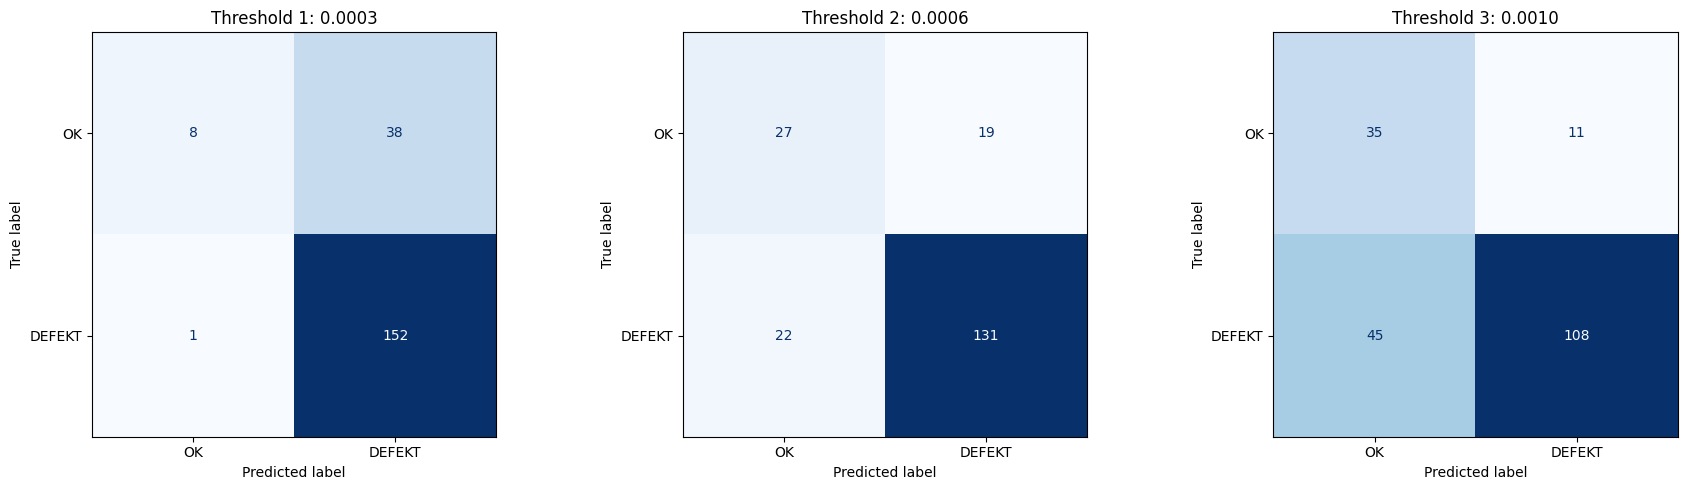

In [10]:
test_normal_scores = get_anomaly_scores(test_good_loader, model, device)
test_defect_scores = get_anomaly_scores(test_def_loader, model, device)

y_test_true = np.concatenate([
    np.zeros(len(test_normal_scores), dtype=int),
    np.ones(len(test_defect_scores), dtype=int)
])
y_test_scores = np.concatenate([test_normal_scores, test_defect_scores])

thresh_1 = RECON_THRESH
thresh_2 = RECON_THRESH * 2 
thresh_3 = RECON_THRESH * 3

print("=" * 60)
print("POROVNANIE VÝSLEDKOV PRE RÔZNE HODNOTY THRESHOLD (Test Set)")
print("=" * 60)
table_header = f"| {'Threshold':^12} | {'Precision':^10} | {'Recall (Defekty)':^18} | {'F1-Score':^10} | {'Falošné Detekcie (FP)':^23} |"
print(table_header)
print("|" + "-"*14 + "|" + "-"*12 + "|" + "-"*20 + "|" + "-"*12 + "|" + "-"*25 + "|")

for t in [thresh_1, thresh_2, thresh_3]:
    y_pred_t = (y_test_scores > t).astype(int)
    cm_t = confusion_matrix(y_test_true, y_pred_t)
    fp_count = cm_t[0, 1] 
    
    prec = precision_score(y_test_true, y_pred_t, zero_division=0)
    rec = recall_score(y_test_true, y_pred_t, zero_division=0)
    f1_s = f1_score(y_test_true, y_pred_t, zero_division=0)
    
    row = f"| {t:^12.5f} | {prec:^10.4f} | {rec:^18.4f} | {f1_s:^10.4f} | {fp_count:^23} |"
    print(row)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
thresholds_list = [thresh_1, thresh_2, thresh_3]
titles = [f'Threshold 1: {thresh_1:.4f}', f'Threshold 2: {thresh_2:.4f}', f'Threshold 3: {thresh_3:.4f}']

for i, t in enumerate(thresholds_list):
    y_pred_t = (y_test_scores > t).astype(int)
    cm_t = confusion_matrix(y_test_true, y_pred_t)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_t, display_labels=['OK', 'DEFEKT'])
    disp.plot(cmap='Blues', ax=axes[i], values_format='d', colorbar=False)
    axes[i].set_title(titles[i])

plt.tight_layout()
plt.show()

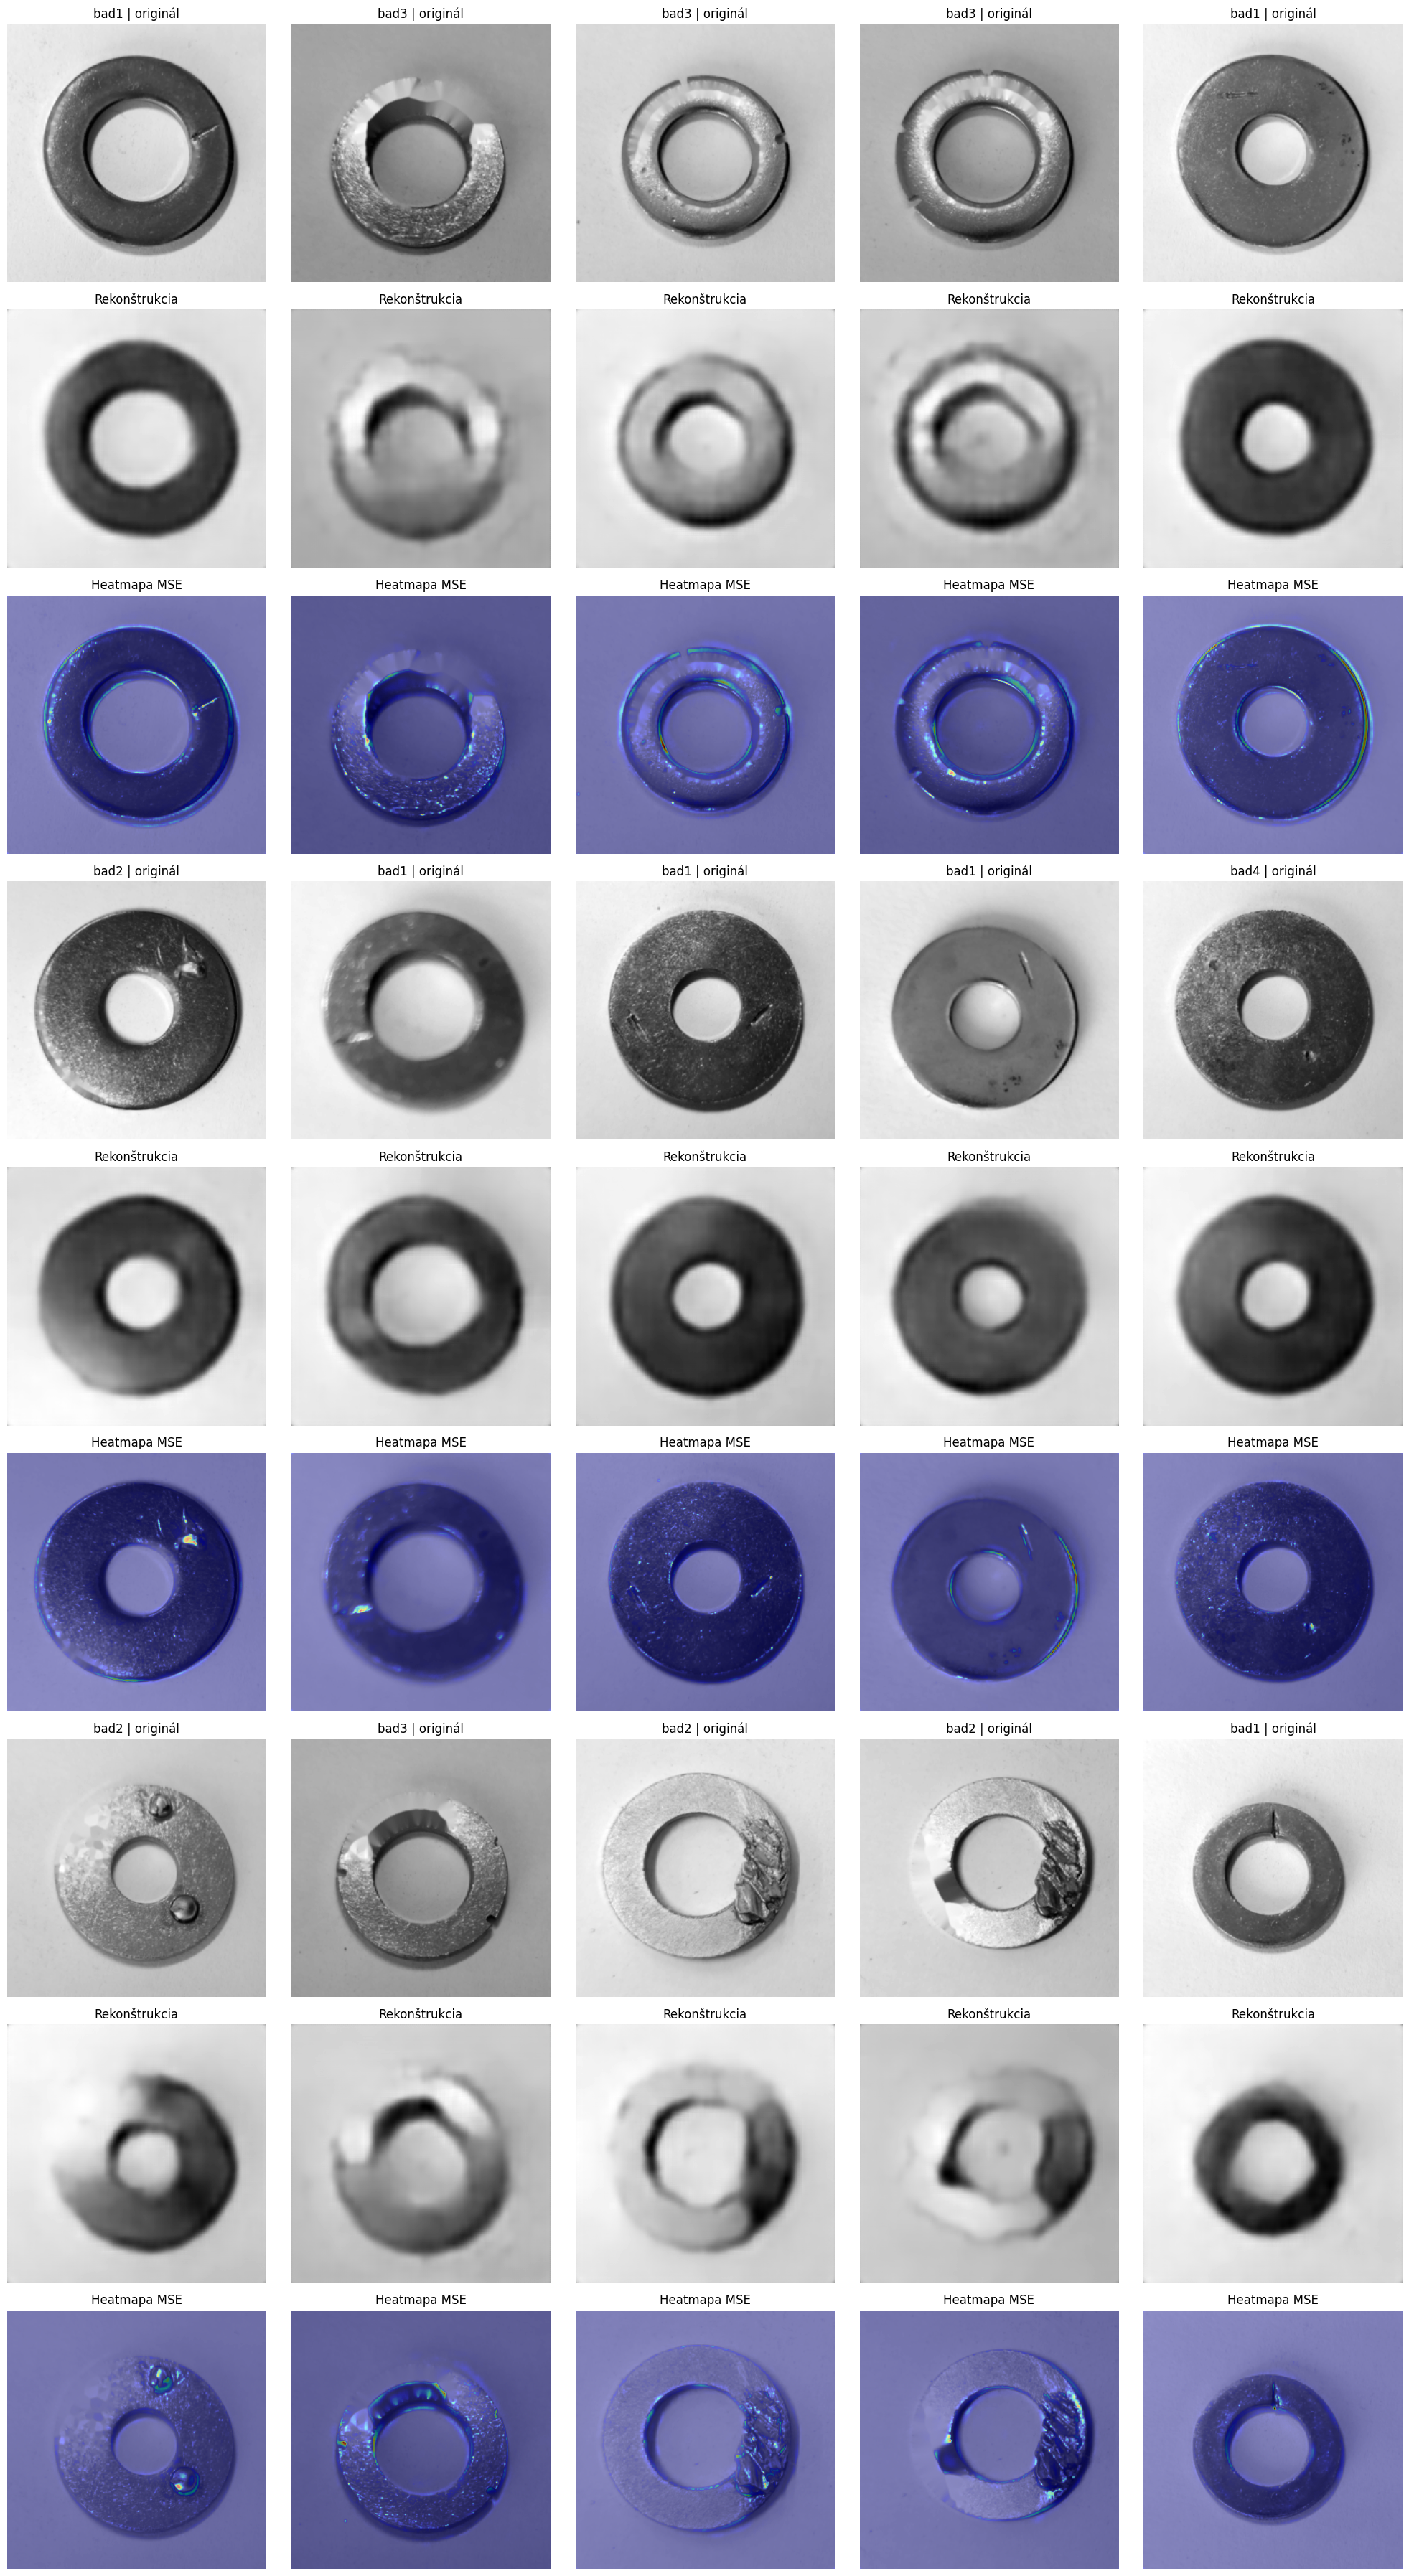

In [13]:
def show_anomaly_heatmaps(model, dataset, subset_loader, device, num_images=15, num_cols=5):
    model.eval()
    subset_indices = subset_loader.dataset.indices
    num_images = min(num_images, len(subset_indices))
    random_indices = random.sample(subset_indices, num_images)
    random_images = []
    random_labels = []
    
    for idx in random_indices:
        img, label = dataset[idx]
        random_images.append(img)
        random_labels.append(dataset.classes[label])
        
    images = torch.stack(random_images).to(device)
    with torch.no_grad():
        reconstructions = model(images)
        error_maps = torch.square(reconstructions - images)
        
    num_blocks = math.ceil(num_images / num_cols)
    fig, axes = plt.subplots(num_blocks * 3, num_cols, figsize=(4 * num_cols, 4 * num_blocks * 3))
    
    for i in range(num_images):
        block = i // num_cols
        col = i % num_cols
        orig_row = block * 3
        rec_row = block * 3 + 1
        heat_row = block * 3 + 2
        
        img_np = images[i].cpu().squeeze().numpy()
        rec_np = reconstructions[i].cpu().squeeze().numpy()
        err_np = error_maps[i].cpu().squeeze().numpy()
        
        axes[orig_row, col].imshow(img_np, cmap='gray')
        axes[orig_row, col].set_title(f"{random_labels[i]} | originál")
        axes[orig_row, col].axis('off')
        
        axes[rec_row, col].imshow(rec_np, cmap='gray')
        axes[rec_row, col].set_title("Rekonštrukcia")
        axes[rec_row, col].axis('off')
        
        axes[heat_row, col].imshow(img_np, cmap='gray')
        axes[heat_row, col].imshow(err_np, cmap='jet', alpha=0.45)
        axes[heat_row, col].set_title("Heatmapa MSE")
        axes[heat_row, col].axis('off')
        
    total_slots = num_blocks * num_cols
    for i in range(num_images, total_slots):
        block = i // num_cols
        col = i % num_cols
        axes[block * 3, col].axis('off')
        axes[block * 3 + 1, col].axis('off')
        axes[block * 3 + 2, col].axis('off')
        
    plt.tight_layout()
    plt.show()

show_anomaly_heatmaps(model, dataset_test, test_def_loader, device, num_images=15)